In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"
!nvidia-smi
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import  sklearn
from sklearn.model_selection import train_test_split
#import ray
import os
import math
import matplotlib.pyplot as plt
import tensorflow.keras.optimizers.schedules as schedules
import pickle
from sklearn.metrics import f1_score

from bayes_opt import BayesianOptimization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
import logging
from tensorflow.keras.optimizers import SGD

Sat Dec  9 04:38:37 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.61.05    Driver Version: 520.61.05    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A6000    On   | 00000000:1A:00.0 Off |                  Off |
| 30%   34C    P2    68W / 300W |   5687MiB / 49140MiB |      3%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A6000    On   | 00000000:1B:00.0 Off |                  Off |
| 30%   

2023-12-09 04:38:38.294342: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-09 04:38:38.525507: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-12-09 04:38:38.586053: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-09 04:38:40.198708: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [2]:


tf.get_logger().setLevel(logging.ERROR)


gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        



originaldir = os.getcwd()
## Change to the directory of where you keep your files.
os.chdir('/nfs/home/dem1110/Assignment 4/')


train_X_all = np.load('train_X.npy', allow_pickle=True)
train_Y_all  = np.load('train_y.npy', allow_pickle=True)
test_X = np.load('test_X.npy', allow_pickle=True)
test_Y = np.load('test_y.npy', allow_pickle=True)


os.chdir(originaldir)
os.getcwd()

train_X_all.shape

train_Y_all.shape

test_X.shape


(1049, 28, 28)

In [3]:

"""### Splitting the data into training and validation

"""

# Split the data into training and validation sets
x_train, x_val= train_test_split(
    train_X_all,
    test_size=0.2,
    random_state=42)

y_train, y_val= train_test_split(
    train_Y_all,
    test_size=0.2,
    random_state=42)


train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
#combined_dataset = train_dataset.concatenate(val_dataset)
x_val_tf = tf.convert_to_tensor(x_val)

type(x_train)



x_train.shape

len(train_dataset)


2023-12-09 04:38:44.108384: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-09 04:38:44.939148: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 44855 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:b1:00.0, compute capability: 8.6


7613

In [4]:

"""### Define model function & function that takes variables and runs the model."""



def macro_f1(y_true, y_pred):
    # Convert softmax probabilities to class predictions
    y_pred_classes = tf.argmax(y_pred, axis=1, output_type=tf.int32)
    y_true_classes = tf.cast(y_true, tf.int32)

    def _numpy_f1_score(y_true, y_pred):
        return f1_score(y_true, y_pred, average='macro')

    # Use tf.py_function to wrap the NumPy function
    ##so that it can be executed within TensorFlow's computational graph
    f1 = tf.py_function(_numpy_f1_score, (y_true_classes, y_pred_classes), tf.float64)
    return f1





In [5]:


E = 500
lr = 0.01
best_activation = 'tanh'
best_batch_size = 29

def build_model( lr, batch_size, activation):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(10, activation='softmax')
    ])

    #model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=[macro_f1])
    custom_optimizer = SGD(learning_rate=lr)

    model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=[macro_f1])
    return model
    
    
    return model

best_model = build_model(lr, best_batch_size, best_activation)
history = best_model.fit(np.concatenate((x_train, x_val)), np.concatenate((y_train, y_val)),
                         epochs=E, batch_size=best_batch_size, verbose=1)














Epoch 1/500
 25/329 [=>............................] - ETA: 1s - loss: 2.3676 - macro_f1: 0.0366

2023-12-09 04:38:47.101269: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


329/329 [==============================] - 4s 7ms/step - loss: 2.0756 - macro_f1: 0.1990
Epoch 2/500
329/329 [==============================] - 2s 6ms/step - loss: 1.5820 - macro_f1: 0.4494
Epoch 3/500
329/329 [==============================] - 2s 7ms/step - loss: 1.2052 - macro_f1: 0.6068
Epoch 4/500
329/329 [==============================] - 2s 6ms/step - loss: 0.9744 - macro_f1: 0.6779
Epoch 5/500
329/329 [==============================] - 2s 6ms/step - loss: 0.8319 - macro_f1: 0.7154
Epoch 6/500
329/329 [==============================] - 2s 7ms/step - loss: 0.7515 - macro_f1: 0.7485
Epoch 7/500
329/329 [==============================] - 2s 6ms/step - loss: 0.6804 - macro_f1: 0.7681
Epoch 8/500
329/329 [==============================] - 2s 7ms/step - loss: 0.6474 - macro_f1: 0.7652
Epoch 9/500
329/329 [==============================] - 3s 9ms/step - loss: 0.6034 - macro_f1: 0.7847
Epoch 10/500
329/329 [==============================] - 2s 7ms/step - loss: 0.5824 - macro_f1: 0.7860
E

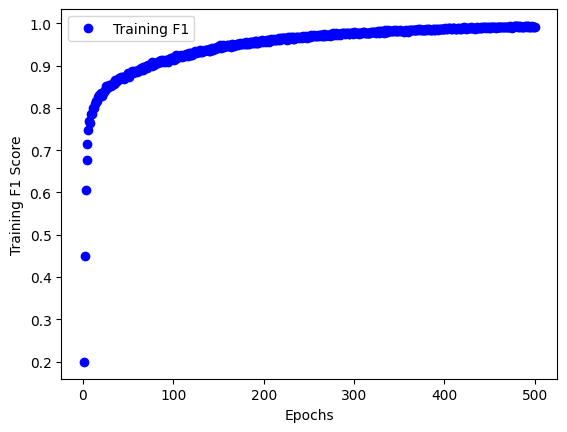

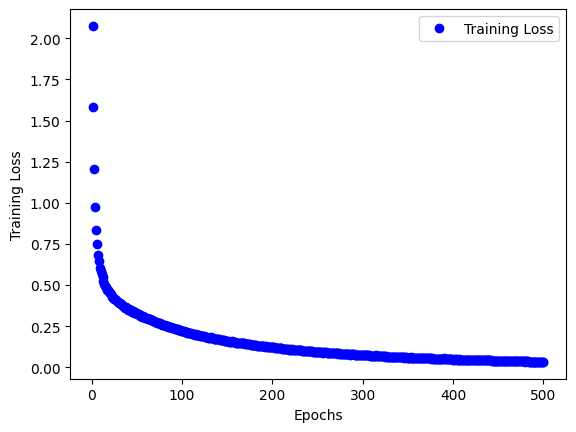

33/33 [==============================] - 0s 1ms/step
Test F1 Score: 0.9664347447854729
33/33 [==============================] - 0s 6ms/step - loss: 0.1351 - macro_f1: 0.9596
Test Loss: 0.13510747253894806


In [6]:
# plot training F1 score versus epochs
train_f1 = history.history['macro_f1']
epochs = range(1, len(train_f1) + 1)
plt.plot(epochs, train_f1, 'bo', label='Training F1')
plt.xlabel('Epochs')
plt.ylabel('Training F1 Score')
plt.legend()
plt.savefig("p2- train data fitness.png")
plt.show()


# plot training loss
train_loss = history.history['loss']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs, train_loss, 'bo', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.savefig("p2-train-data-loss.png")
plt.show()


# evaluate on test data
test_preds = np.argmax(best_model.predict(test_X), axis=1)
test_f1 = f1_score(test_Y, test_preds, average='macro')
print("Test F1 Score:", test_f1)

# get test loss
test_loss = best_model.evaluate(test_X, test_Y)[0]
print("Test Loss:", test_loss)
